# 决策树

决策树（decision tree）是一个树结构（可以是二叉树或非二叉树）。  
其每个非叶节点表示一个特征属性上的测试，每个分支代表这个特征属性在某个值域上的输出，而每个叶节点存放一个类别。  
使用决策树进行决策的过程就是从根节点开始，测试待分类项中相应的特征属性，并按照其值选择输出分支，直到到达叶子节点，将叶子节点存放的类别作为决策结果。


下图就是一个由四个特征作为决策条件的决策树：

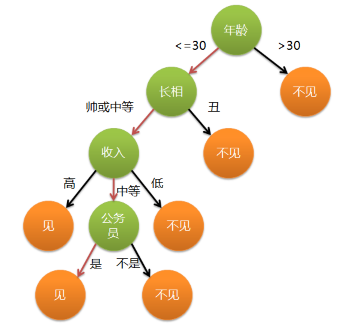

构建决策树，两个问题：
1. 优先选择哪个特征分裂，越快构建决策树越好。（ID3, C4.5, CART）
2. 分裂特征时，如何选择分裂的标准：一个原则：分裂的子节点，越纯越好。

## ID3算法

对于如何优选选择哪个特征进行分裂，有多种算法，ID3算法是其中之一，它与信息熵有关。

对信息熵的了解，参考知乎网站上Pulsar的回答：https://www.zhihu.com/question/22178202/answer/3385409036

熵在信息论中代表随机变量不确定度的度量。一个离散型随机变量X的熵$H(X)$定义为:
$$
H(X) = - \sum\limits_{x \in X}p(x)logp(x)
$$

其中，x是对于随机变量X的每种结果x  
p(x)表示x发生的概率  
所有p(x)logp(x)求和后取负，表示随机变量X的信息熵，也就是X的不确定量。  
由于p(x)总是小于等于1，因此log(x)总是小于等于0，因此H(X)的值总是大于等于0的。

假设数据集有四个特征A,B,C,D，目标值为E。上面的信息熵公式可以用来计算出目标值E的信息熵，其中p(x)表示E列每个种类出现的概率。

根据A列对E列值进行划分的信息熵：

$$
H(AX) = \sum\limits_{a \in A} p(a)H(X_{a})
$$

其中，p(a)表示A列中每种类别的概率，  
$H(X_{a})$表示在a类别下，E列的信息熵

信息增益即为两者差值：

$$
gain(A) = H(AX) - H(X)
$$

gain(A)为小于等于0的值。因为，新增一列的信息后，信息熵肯定是不变或减小了，不可能增加。

下面以一个根据三个特征判断账号是否真实的数据集为例，手动计算下信息增益。

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.DataFrame({"日志密度" : ['s','s','l','m','l','m','m','l','m','s'],
                   "好友密度" : ['s','l','m','m','m','l','s','m','s','s'],
                   '是否使用真实头像' : ['no','yes','yes','yes','yes','no','no','no','no','yes'],
                   "账号是否真实" : ['no','yes','yes','yes','yes','yes','no','yes','yes','no']})
df

In [ ]:
# 计算某列的信息熵
def info_single(df, index):
    # 各分类的概率
    p = df[index].value_counts(normalize=True)
    # 信息熵
    info_sum = 0
    for i,col in enumerate(p):
        info_sum += -1 * p[i] * np.log2(p[i])
    return info_sum

In [ ]:
{i : info_single(df, i) for i in df.columns}

In [ ]:
# 求按index列对账号是否真实进行划分的信息熵和增益。
def info_double(df, index):
    # 当前列分类概率
    p = df[index].value_counts(normalize=True)

    # 信息熵和
    info_sum = 0 
    for t in p.index:
        # 过滤出当前类别当前类别
        sub_df = df[df[index] == t]
        # 计算该分类下yes和no的概率
        prob = sub_df['账号是否真实'].value_counts(normalize=True)
        # print(f'======{index}:{t}=======')
        if 'yes' in prob.index:
            # print(f'真实账号概率:{prob["yes"]}')
            info_sum += p[t] * -1 * prob['yes'] * np.log2(prob['yes'])
        if 'no' in prob.index:
            # print(f'虚假账号概率:{prob["no"]}')
            info_sum += p[t] * -1 * prob['no'] * np.log2(prob['no'])
    return info_single(df, index), info_sum, info_sum - info_single(df, '账号是否真实')

In [ ]:
info_double(df, '日志密度')

In [ ]:
pd.DataFrame(data = {i : info_double(df, i) for i in df.columns}, index=['当前列的信息熵','当前列对账号真实分类的信息熵', '信息熵增益'])

结论：使用好友密度对账号真实分类的信息熵增益最高，因此首先使用好友密度进行分类。

  以上是ID3算法选择分类特征的过程。

ID3的优点：简单，好理解。

缺点：1.大量对数运算，对计算机不友好。2. 容易优先对比较离散的特征进行划分，可能会导致分类错误。

## C4.5算法

C4.5算法是对ID3的改良：让信息熵增益除以特征本身的信息熵。人为降低离散特征的信息增益。

使用信息增益率来选择分类特征。

下面新增一列ID数据，来展示ID3和C4.5在分类特征筛选结果上的区别。

In [ ]:
df2 = df.copy()
df2.insert(0, "ID", range(len(df)))

In [ ]:
df2

In [ ]:
# 可以看到，由于ID列的信息熵值很高，因此会优先按ID列划分，这明显不是我们想要的，每个id的账号真实情况确定，但账号是否真实不应该按id划分。
pd.DataFrame(data = {i : info_double(df2, i) for i in df2.columns}, index=['当前列的信息熵','当前列对账号真实分类的信息熵', '信息熵增益'])

C4.5算法使用信息增益率代替信息增益作为特征选择的条件：

$$
信息增益率 = \frac{信息增益}{特征信息熵}
$$

对取值多的特征做惩罚，让选择更合理。

In [ ]:
# 求按index列对账号是否真实进行划分的信息熵和增益率。
def info_rate_double(df, index):
    # 当前列分类概率
    p = df[index].value_counts(normalize=True)

    # 信息熵和
    info_sum = 0 
    for t in p.index:
        # 过滤出当前类别当前类别
        sub_df = df[df[index] == t]
        # 计算该分类下yes和no的概率
        prob = sub_df['账号是否真实'].value_counts(normalize=True)
        # print(f'======{index}:{t}=======')
        if 'yes' in prob.index:
            # print(f'真实账号概率:{prob["yes"]}')
            info_sum += p[t] * -1 * prob['yes'] * np.log2(prob['yes'])
        if 'no' in prob.index:
            # print(f'虚假账号概率:{prob["no"]}')
            info_sum += p[t] * -1 * prob['no'] * np.log2(prob['no'])
    return info_single(df, index), info_sum, (info_sum - info_single(df, '账号是否真实')) / info_single(df, index)

In [ ]:
# 可以看到C4.5算法会优先选择好友密度进行划分。
pd.DataFrame(data = {i : info_rate_double(df2, i) for i in df2.columns}, index=['当前列的信息熵','当前列对账号真实分类的信息熵', '信息熵增益率'])

## CART算法

CART算法: classification and regression tree 分类和回归树  
ID3和C4.5只能做分类任务，CART既可以做分类，也可以做回归  
CART树是二叉树  
CART算法通过计算基尼不纯度：gain impurity  
思想上跟计算信息增益很像，CART把计算信息熵换成了计算基尼系数。

基尼系数：

$$
gini(X) = 1 - \sum\limits_{x \in X} p(x)^2
$$

其中，gini(X)表示随机变量X的基尼系数    
p(x)表示X的其中一种分类x的概率

使用A列对E列划分的基尼系数：

$$
gini(AX) = \sum\limits_{a \in A} p(a)gini(X_{a})
$$

其中，p(a)表示A列的某个分类a的概率  
$gini(X_a)$表示在A列为a的情况下E列的基尼系数。

使用A列对E列进行划分的基尼不纯度：

$$
giniip(A) = gini(AX) - gini(X)
$$

In [ ]:
# 计算某列的基尼系数
def gini_single(df, index):
    # 各分类的概率
    p = df[index].value_counts(normalize=True)
    # 基尼系数
    gini_sum = 1
    for i,col in enumerate(p):
        gini_sum -= p[i] ** 2
    return gini_sum

In [ ]:
{i : gini_single(df2, i) for i in df2.columns}

In [ ]:
# 求按index列对账号是否真实进行划分的基尼系数和不纯度。
def gini_double(df, index):
    # 当前列分类概率
    p = df[index].value_counts(normalize=True)

    # 基尼系数
    gini_sum = 0 
    for t in p.index:
        # 过滤出当前类别当前类别
        sub_df = df[df[index] == t]
        # 计算该分类下yes和no的概率
        prob = sub_df['账号是否真实'].value_counts(normalize=True)
        # print(f'======{index}:{t}=======')
        gini_sum_tmp = 1
        if 'yes' in prob.index:
            # print(f'真实账号概率:{prob["yes"]}')
            gini_sum_tmp -= prob['yes'] ** 2
        if 'no' in prob.index:
            # print(f'虚假账号概率:{prob["no"]}')
            gini_sum_tmp -= prob['no'] ** 2
        gini_sum += p[t] * gini_sum_tmp
    return gini_single(df, index), gini_sum, gini_sum - gini_single(df, '账号是否真实')

In [ ]:
pd.DataFrame(data = {i : gini_double(df2, i) for i in df2.columns}, index=['当前列的基尼系数','当前列对账号真实分类的基尼系数', '基尼不纯度'])

可以看到，CART算法在除ID列外会优先选择好友密度特征进行划分。

CART算法同样会偏好取值多的特征，但是由于不用对数，以及是二叉树分类，不会一次直接按所有类别分叉，因此没有ID3算法偏好程度重。

在实战中可以通过设置最大树深度等参数来解决这个问题。

## 三种算法的对比

| 对比项 | ID3 | C4.5 | CART |
| --- | --- | --- | --- |
| 划分准则 | 信息增益 | 信息增益率 | 基尼不纯度 |
| 特征类型 | 仅离散 | 离散+连续 | 离散+连续 |
| 树结构 | 多叉树 | 多叉树 | 二叉树 |
| 任务类型 | 分类 | 分类 | 分类+回归 |

使用决策树，KNN，逻辑斯蒂回归对鸢尾花数据集进行分类。·

决策树的优缺点：

决策树剪枝

 用决策树回归

画出决策树的分类边界线，注意观察不同参数的分类边界线的效果。

随机森林

集成算法

自学：Alot智能物联网-决策树系列算法和京东天猫项目